In [ ]:
!pip install networkx pandas numpy torch opencv-python matplotlib seaborn scikit-learn plotly rpy2 cdlib libpysal spreg captum pysnooper fire
!pip install torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.7 MB/s eta 0:00:00


In [ ]:
import matplotlib
import pandas as pd
import torch
import pickle
import networkx as nx, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from networkx.algorithms import centrality
from torch_geometric.utils.convert import to_networkx, from_networkx
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
from torch import nn
from torch_geometric.transforms import RandomNodeSplit

In [ ]:
import json

# Load the JSON data
with open('physician_network.json', 'r') as file:
    data = json.load(file)

G = nx.Graph()

# Add nodes with attributes
for node in data['nodes']:
    G.add_node(node['id'][0], **{k: v[0] for k, v in node.items() if k != 'id'})

# Add edges with attributes
for edge in data['edges']:
    G.add_edge(edge['source'][0], edge['target'][0], **{k: v[0] for k, v in edge.items() if k not in ['source', 'target']})

for node, data in G.nodes(data=True):
    # Check if the year attribute is a sentinel value
    if data.get('adoption date') in [98, 99]:
      # Update the attribute to NaN in the graph
      G.nodes[node]['adoption date'] = np.nan
    if data.get('adoption date') == 18:
      G.nodes[node]['adoption date'] = np.nan

for node in G.nodes():
  print(G.nodes[node]['adoption date'])

1
12
8
9
9
10
nan
3
11
2
4
5
2
15
4
15
nan
5
11
2
8
7
5
4
3
6
1
5
3
15
5
7
6
14
4
8
8
14
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
4
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
11
12
1
6
7
1
6
nan
4
nan
nan
nan
nan
nan
nan
nan
7
6
1
2
5
13
4
3
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan


In [ ]:
# return Practice vertex attribute, assign to color

def generate_color_map(node_attributes):
    unique_values = set(node_attributes.values())
    palette = sns.color_palette("hls", len(unique_values))
    color_lookup = dict(zip(unique_values, palette))

    # Iterate through G.nodes() to ensure correct order and size (106 elements)
    return [color_lookup[node_attributes[node]] for node in G.nodes()]

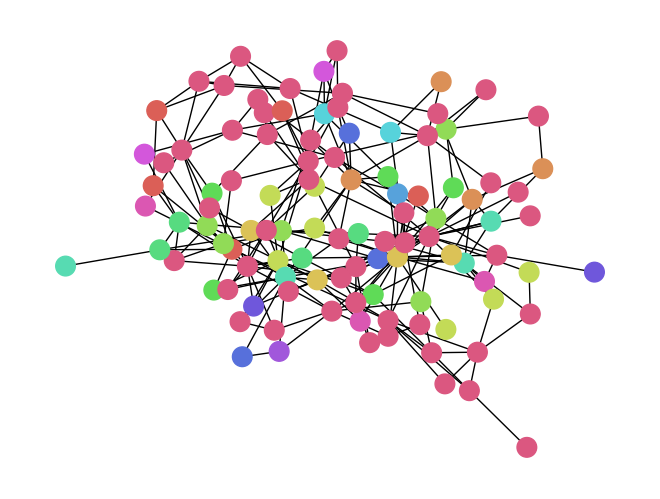

In [ ]:
# plot network, color by practice
np.random.seed(42)
# fr layout
pos = nx.spring_layout(G,iterations=200)
color_map = generate_color_map(nx.get_node_attributes(G, 'adoption date'))
nx.draw(G, pos, node_size=200, node_color=color_map, font_size=10, with_labels=False)

In [ ]:
from cdlib.algorithms import leiden, louvain

In [ ]:
np.random.seed(42)
node_clustered=louvain(G, resolution=0.99)
node_clustered={k:v[0] for k,v in node_clustered.to_node_community_map().items()}
nx.set_node_attributes(G, node_clustered, "louvain")

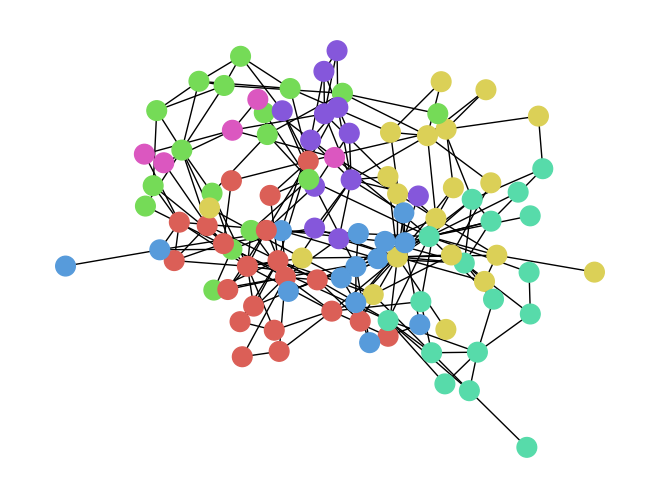

In [ ]:
color_map = generate_color_map(nx.get_node_attributes(G, 'louvain'))
nx.draw(G, pos, node_size=200, node_color=color_map, font_size=10, with_labels=False)

In [ ]:
clustering = SpectralClustering(n_clusters=5, assign_labels="discretize",
                                random_state=0, affinity="precomputed").fit(nx.to_numpy_array(G))

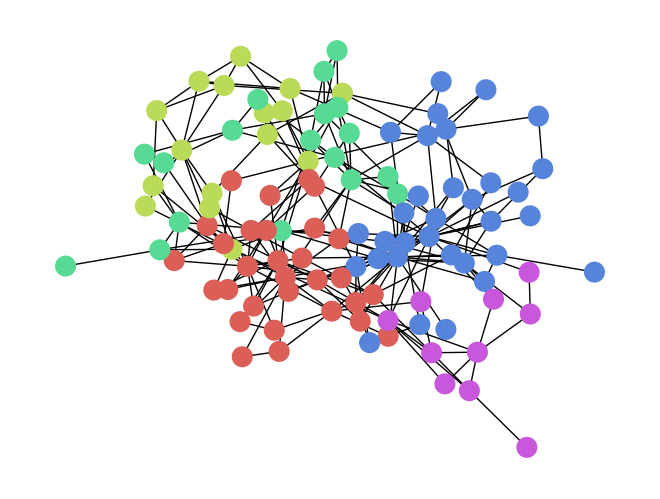

In [ ]:
nx.set_node_attributes(G, dict(zip(G.nodes(), clustering.labels_)), "spectral")
color_map = generate_color_map(nx.get_node_attributes(G, 'spectral'))
nx.draw(G, pos, node_size=200, node_color=color_map, font_size=10, with_labels=False)

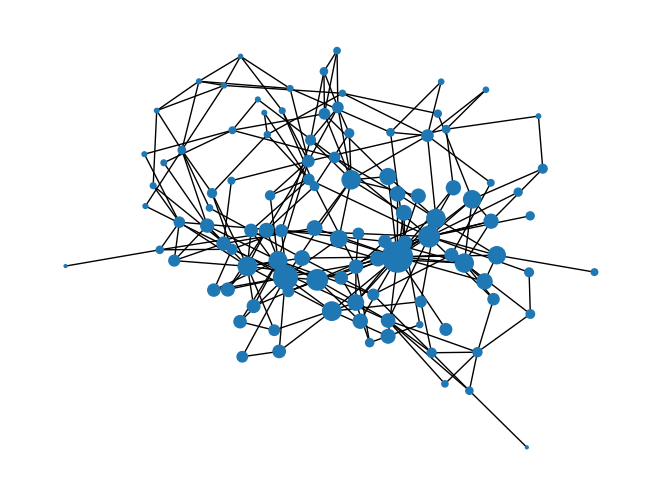

In [ ]:
# identify centrality of each node
centrality=nx.eigenvector_centrality(G)
nx.set_node_attributes(G, centrality, "eigenvector")
# size nodes by centrality
node_size = [v * 1000 for v in nx.get_node_attributes(G, 'eigenvector').values()]
nx.draw(G, pos, node_size= node_size, font_size=10, with_labels=False)

In [ ]:
pyg_graph = from_networkx(G)

print(pyg_graph)
print(pyg_graph.adoption_date)

Data(edge_index=[2, 462], city=[106], med_sch_yr=[106], meetings=[106], jours=[106], free_time=[106], discuss=[106], clubs=[106], friends=[106], community=[106], patients=[106], proximity=[106], specialty=[106], louvain=[106], spectral=[106], eigenvector=[106], adoption_date=[106], relation=[462], num_nodes=106)
tensor([ 1., 12.,  8.,  9.,  9., 10., nan,  3., 11.,  2.,  4.,  5.,  2., 15.,
         4., 15., nan,  5., 11.,  2.,  8.,  7.,  5.,  4.,  3.,  6.,  1.,  5.,
         3., 15.,  5.,  7.,  6., 14.,  4.,  8.,  8., 14., nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan,  4., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, 11.,
        12.,  1.,  6.,  7.,  1.,  6., nan,  4., nan, nan, nan, nan, nan, nan,
        nan,  7.,  6.,  1.,  2.,  5., 13.,  4.,  3., nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan])


In [ ]:
feature_list = [
    'city', 'med_sch_yr', 'meetings', 'jours', 'free_time',
    'discuss', 'clubs', 'friends', 'community',
    'patients', 'proximity', 'specialty',
    'louvain', 'spectral', 'eigenvector'
]

feature_tensors = []

for feature in feature_list:
    tensor = pyg_graph[feature]

    # Ensure float + correct shape
    tensor = tensor.view(-1).float()

    feature_tensors.append(tensor)

X = torch.stack(feature_tensors, dim=1)

# Normalize
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X.numpy())

pyg_graph.x = torch.tensor(X, dtype=torch.float)

In [ ]:
adoption = pyg_graph["adoption date"].float()

valid_mask = ~torch.isnan(adoption)
#valid_mask = valid_mask & (adoption < 20)

pyg_graph.y = adoption.long()

valid_indices = valid_mask.nonzero(as_tuple=True)[0]

perm = valid_indices[torch.randperm(valid_indices.numel())]

num_test = int(0.2 * len(perm))

test_idx = perm[:num_test]
train_idx = perm[num_test:]

pyg_graph.train_mask = torch.zeros(pyg_graph.num_nodes, dtype=torch.bool)
pyg_graph.test_mask = torch.zeros(pyg_graph.num_nodes, dtype=torch.bool)

pyg_graph.train_mask[train_idx] = True
pyg_graph.test_mask[test_idx] = True

print(f"Nodes in train: {pyg_graph.train_mask.sum().item()}")
print(f"Nodes in test: {pyg_graph.test_mask.sum().item()}")

Nodes in train: 43
Nodes in test: 10


In [ ]:
class GCN(nn.Module):
    def __init__(self, inputDim, hiddenDim, outputDim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(inputDim, hiddenDim)
        self.conv2 = GCNConv(hiddenDim, outputDim)

    def forward(self, featureData, edgeInfo):
        x = self.conv1(featureData, edgeInfo)
        x = F.relu(x)
        x = F.dropout(x, p = 0.5, training = self.training)
        #Second GCN layer
        x = self.conv2(x, edgeInfo)
        return x

# Initialize the model
num_features=pyg_graph.x.shape[1]
GCNmodel = GCN(num_features, 16, 1)

optimizer = torch.optim.Adam(GCNmodel.parameters(), lr = 0.01, weight_decay = 5e-4)

In [ ]:
criterion = torch.nn.MSELoss()
def trainModel():
  GCNmodel.train()
  optimizer.zero_grad()
  output = GCNmodel(pyg_graph.x, pyg_graph.edge_index)
  trainPredOnly = output[pyg_graph.train_mask].squeeze()
  pyg_graph.y = pyg_graph["adoption date"].float()
  trainLabelsOnly = pyg_graph.y[pyg_graph.train_mask]
  loss = criterion(trainPredOnly, trainLabelsOnly)
  loss.backward()
  optimizer.step()
  return loss.item()

for epoch in range(200):
  lossValue = trainModel()
  print(f'Epoch: {epoch+1:03d}, Loss: {lossValue:.4f}')

Epoch: 001, Loss: 56.8372
Epoch: 002, Loss: 55.9568
Epoch: 003, Loss: 54.3227
Epoch: 004, Loss: 53.6690
Epoch: 005, Loss: 53.4968
Epoch: 006, Loss: 51.7178
Epoch: 007, Loss: 50.8880
Epoch: 008, Loss: 48.4833
Epoch: 009, Loss: 47.3408
Epoch: 010, Loss: 48.6529
Epoch: 011, Loss: 45.4491
Epoch: 012, Loss: 44.0524
Epoch: 013, Loss: 43.4568
Epoch: 014, Loss: 44.5077
Epoch: 015, Loss: 42.6098
Epoch: 016, Loss: 43.6327
Epoch: 017, Loss: 40.5293
Epoch: 018, Loss: 38.2902
Epoch: 019, Loss: 39.7287
Epoch: 020, Loss: 36.9415
Epoch: 021, Loss: 35.8630
Epoch: 022, Loss: 35.2852
Epoch: 023, Loss: 35.2522
Epoch: 024, Loss: 33.5680
Epoch: 025, Loss: 30.4235
Epoch: 026, Loss: 29.3035
Epoch: 027, Loss: 28.1308
Epoch: 028, Loss: 32.4567
Epoch: 029, Loss: 29.6120
Epoch: 030, Loss: 24.9769
Epoch: 031, Loss: 30.5305
Epoch: 032, Loss: 27.5538
Epoch: 033, Loss: 28.0881
Epoch: 034, Loss: 23.6576
Epoch: 035, Loss: 25.6723
Epoch: 036, Loss: 24.3964
Epoch: 037, Loss: 24.2683
Epoch: 038, Loss: 24.4927
Epoch: 039, 

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

GCNmodel.eval()
with torch.no_grad():
    output = GCNmodel(pyg_graph.x, pyg_graph.edge_index)
    predictions = output[pyg_graph.test_mask].squeeze()
    actuals = pyg_graph['adoption date'][pyg_graph.test_mask]
    assert not torch.isnan(actuals).any(), "NaNs in test labels!"

    pred_np = predictions.cpu().numpy()
    actual_np = actuals.cpu().numpy()

    mae = mean_absolute_error(actual_np, pred_np)
    mse = mean_squared_error(actual_np, pred_np)
    rmse = np.sqrt(mse)

    print(f"MAE: {mae:.3f}")
    print("MSE:", mse)
    print(f"RMSE: {rmse:.3f}")

MAE: 2.678
MSE: 10.070405960083008
RMSE: 3.173


In [ ]:
X = pyg_graph.x.cpu().numpy()
y = pyg_graph["adoption date"].float().cpu().numpy()

train_mask = pyg_graph.train_mask.cpu().numpy()
test_mask = pyg_graph.test_mask.cpu().numpy()

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [ ]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

pred_linreg = linreg.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_linreg)
mse_lr = mean_squared_error(y_test, pred_linreg)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression")
print(f"MAE: {mae_lr:.3f}")
print(f"MSE: {mse_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")

Linear Regression
MAE: 3.126
MSE: 17.228
RMSE: 4.151


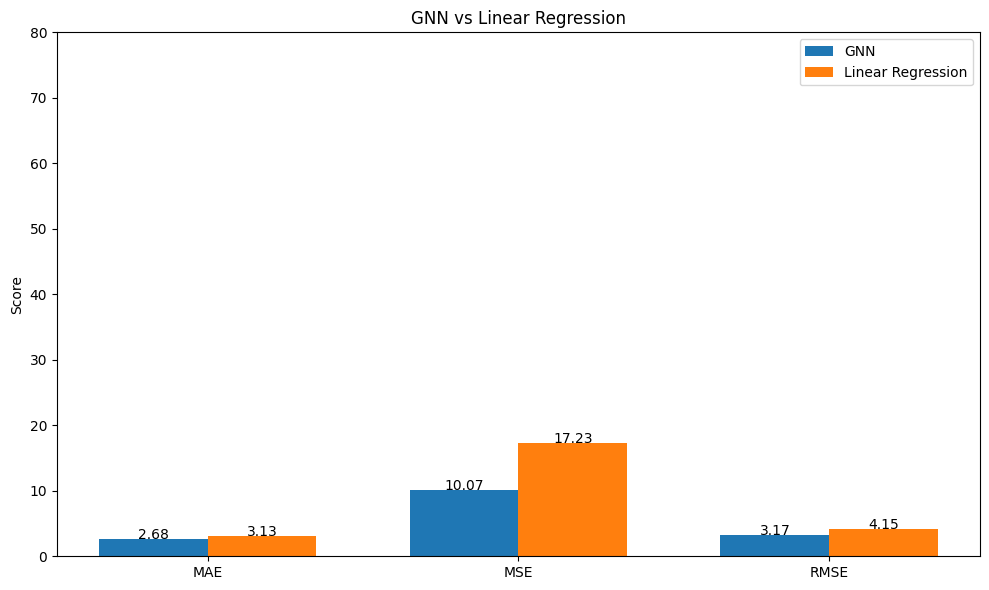

In [ ]:
metrics = ["MAE", "MSE", "RMSE"]

gnn_scores = [mae, mse, rmse]
lr_scores = [mae_lr, mse_lr, rmse_lr]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, gnn_scores, width, label="GNN")
plt.bar(x + width/2, lr_scores, width, label="Linear Regression")

plt.xticks(x, metrics)
plt.ylim(0, 80.0)
plt.ylabel("Score")
plt.title("GNN vs Linear Regression")
plt.legend()

for i, score in enumerate(gnn_scores):
    plt.text(i - width/2, score + 0.02, f"{score:.2f}", ha="center")

for i, score in enumerate(lr_scores):
    plt.text(i + width/2, score + 0.02, f"{score:.2f}", ha="center")

plt.tight_layout()
plt.show()